## Question 1 :Verify that the mean of power is centered around the variance of the voltage

In [26]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
M, n = 500, 1000

V           = [np.random.randn(n) for _ in range(M)]
mean_power  = [np.mean(v**2) for v in V]
var_voltage = [np.var(v)     for v in V]

print(f'Mean Power:       {np.mean(mean_power):.4f}')
print(f'Voltage Variance: {np.mean(var_voltage):.4f}')

Mean Power:       1.0009
Voltage Variance: 1.0000


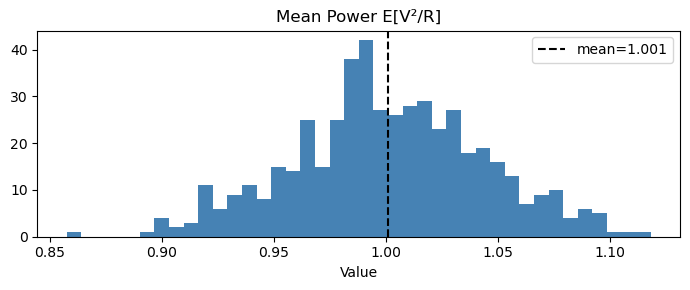

In [21]:
# Plot Mean Power
plt.figure(figsize=(7, 3))
plt.hist(mean_power, bins=40, color='steelblue')
plt.axvline(np.mean(mean_power), color='k', linestyle='--', label=f'mean={np.mean(mean_power):.3f}')
plt.title('Mean Power E[V²/R]'); plt.xlabel('Value'); plt.legend()
plt.tight_layout(); plt.show()

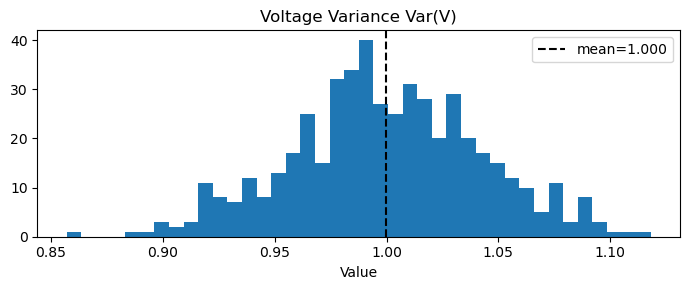

In [28]:
## Voltage Variance
plt.figure(figsize=(7, 3))
plt.hist(var_voltage, bins=40, )
plt.axvline(np.mean(var_voltage), color='k', linestyle='--', label=f'mean={np.mean(var_voltage):.3f}')
plt.title('Voltage Variance Var(V)'); plt.xlabel('Value'); plt.legend()
plt.tight_layout(); plt.show()

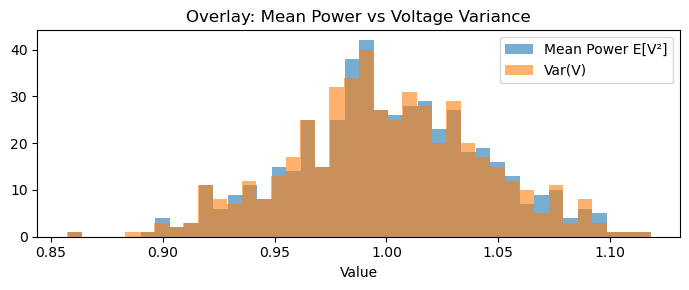

In [29]:
#  Overlay
plt.figure(figsize=(7, 3))
plt.hist(mean_power,  bins=40, alpha=0.6, label='Mean Power E[V²]')
plt.hist(var_voltage, bins=40, alpha=0.6, label='Var(V)')
plt.title('Overlay: Mean Power vs Voltage Variance'); plt.xlabel('Value'); plt.legend()
plt.tight_layout(); plt.show()

## Question 2: Consider cases of different RMS and plot their histograms.

In [32]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 10000
rms_values = [0.5, 1.0, 2.0, 4.0]
signals = {rms: np.random.randn(n) * rms for rms in rms_values}

for rms, v in signals.items():
    print(f'RMS={rms}: measured={np.sqrt(np.mean(v**2)):.4f}')

RMS=0.5: measured=0.5017
RMS=1.0: measured=1.0011
RMS=2.0: measured=1.9829
RMS=4.0: measured=4.0179


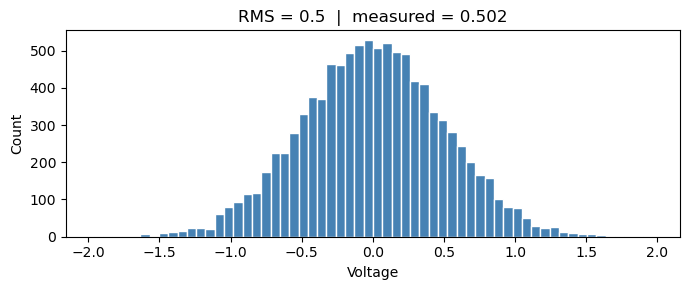

In [33]:
v = signals[0.5]
plt.figure(figsize=(7, 3))
plt.hist(v, bins=60, color='steelblue', edgecolor='white')
plt.title(f'RMS = 0.5  |  measured = {np.sqrt(np.mean(v**2)):.3f}')
plt.xlabel('Voltage'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

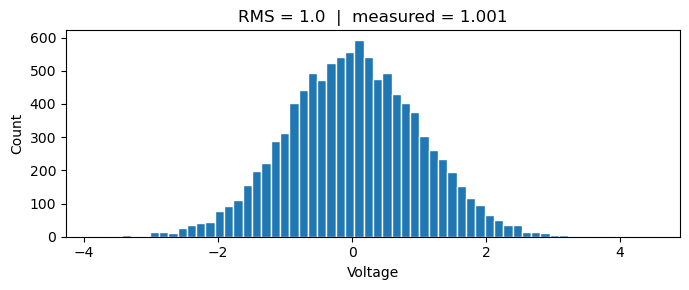

In [35]:
v = signals[1.0]
plt.figure(figsize=(7, 3))
plt.hist(v, bins=60, edgecolor='white')
plt.title(f'RMS = 1.0  |  measured = {np.sqrt(np.mean(v**2)):.3f}')
plt.xlabel('Voltage'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

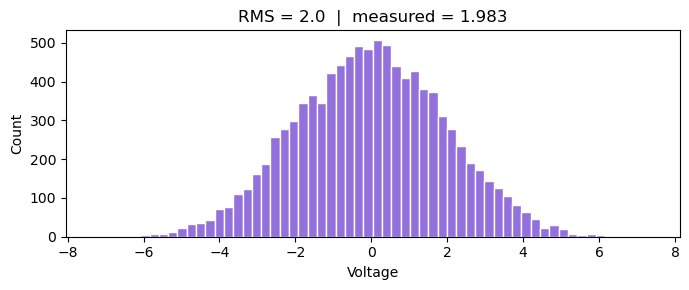

In [36]:
v = signals[2.0]
plt.figure(figsize=(7, 3))
plt.hist(v, bins=60, edgecolor='white')
plt.title(f'RMS = 2.0  |  measured = {np.sqrt(np.mean(v**2)):.3f}')
plt.xlabel('Voltage'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

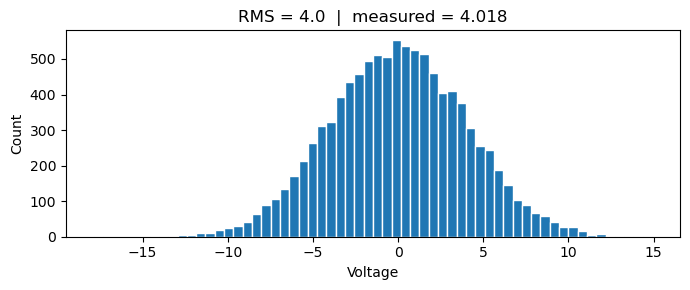

In [38]:
v = signals[4.0]
plt.figure(figsize=(7, 3))
plt.hist(v, bins=60, edgecolor='white')
plt.title(f'RMS = 4.0  |  measured = {np.sqrt(np.mean(v**2)):.3f}')
plt.xlabel('Voltage'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

**Inference**

All four histograms are Gaussian centered at zero. What changes with RMS is only the **spread**:
- Higher RMS → wider, flatter histogram
- Lower RMS → narrower, taller histogram

For zero-mean signals: **RMS = std = sigma**, so scaling RMS scales the standard deviation directly.
Measured RMS matches the target in each case, confirming: **RMS² = Var(V) = E[V²]** ✓

## Question 3 :How will the histogram change if I add a slowly varying sine wave in it.

In [39]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 10000
t        = np.linspace(0, 1, n)
noise    = np.random.randn(n)
sine     = np.sin(2 * np.pi * 2 * t)
combined = noise + sine

print(f'Noise    std = {noise.std():.3f}')
print(f'Sine     std = {sine.std():.3f}')
print(f'Combined std = {combined.std():.3f}')

Noise    std = 1.003
Sine     std = 0.707
Combined std = 1.231


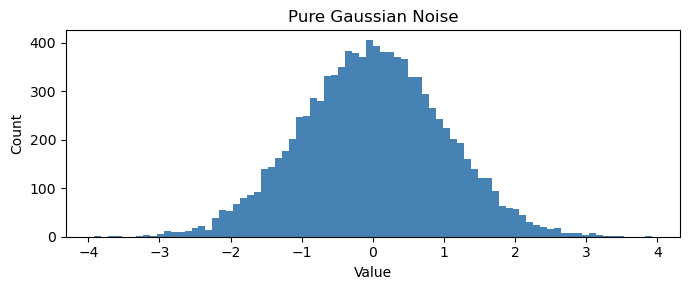

In [40]:
# Plot 1 — Pure Noise
plt.figure(figsize=(7, 3))
plt.hist(noise, bins=80, color='steelblue')
plt.title('Pure Gaussian Noise'); plt.xlabel('Value'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

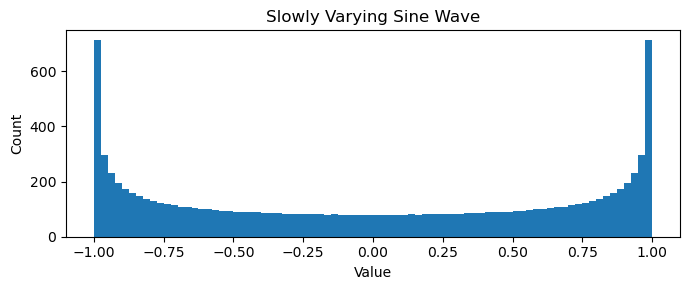

In [44]:
# Plot 2 — Sine Wave
plt.figure(figsize=(7, 3))
plt.hist(sine, bins=80)
plt.title('Slowly Varying Sine Wave'); plt.xlabel('Value'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

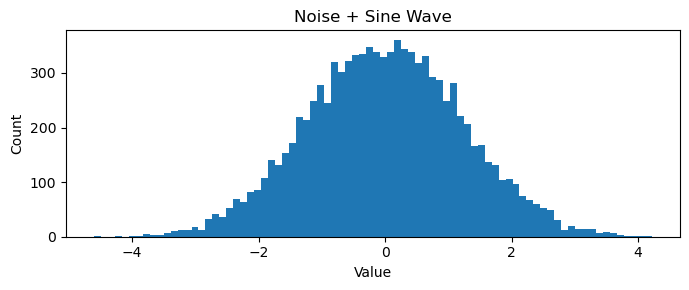

In [43]:
# Plot 3 — Noise + Sine
plt.figure(figsize=(7, 3))
plt.hist(combined, bins=80)
plt.title('Noise + Sine Wave'); plt.xlabel('Value'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

**Inference**

- **Noise (Plot 1)** → Classic bell curve (Gaussian), centered at 0, std ≈ 1.0

- **Sine (Plot 2)** → U-shaped **(arcsine distribution)** — the sine spends more time near its peaks (±1) than near zero, so the histogram piles up at the extremes

- **Combined (Plot 3)** → Still roughly Gaussian but **wider and flatter**: mean stays at 0, std grows from 1.0 → 1.23, because variances add:

  > **Var(noise + sine) = Var(noise) + Var(sine) = 1.0 + 0.5 = 1.5 → std ≈ 1.22 ✓**

Adding a sine wave does **not shift** the histogram center — it only **widens** it.

## Question 4: How are the Variances of the ensembles distributed ? 

In [47]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
M, n = 500, 1000

V         = [np.random.randn(n) for _ in range(M)]
var_noise = [np.var(v) for v in V]

print(f'mean = {np.mean(var_noise):.4f}')
print(f'std  = {np.std(var_noise):.4f}')

mean = 1.0000
std  = 0.0429


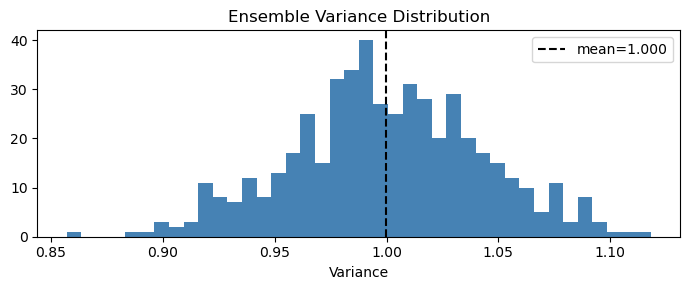

In [48]:
# Plot — Ensemble Variance Distribution
plt.figure(figsize=(7, 3))
plt.hist(var_noise, bins=40, color='steelblue')
plt.axvline(np.mean(var_noise), color='k', linestyle='--', label=f'mean={np.mean(var_noise):.3f}')
plt.title('Ensemble Variance Distribution'); plt.xlabel('Variance'); plt.legend()
plt.tight_layout(); plt.show()

**Inference**

The ensemble variances follow a **chi-squared (χ²) distribution** — right-skewed with a tail to the right.

This comes directly from theory: sample variance of a Gaussian signal scaled by n follows χ²(n−1).

- **Mean ≈ 1.0** — matches the true variance σ² = 1, so the estimator is unbiased  
- **std ≈ 0.04** — small spread due to large n (n=1000); as n→∞ the spike narrows to a delta  
- The variance is **not a fixed number** — it is itself random and distributed across the ensemble